In [54]:
import requests
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# == Machine Learning dependencies ==
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# == Processing text dependencies ==
import nltk
# IF NEEDED...
#nltk.download('punkt')
#nltk.download('stopwords')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Objective

Build topics via Topic modelling with LDA to analyze ...

## Remembering some important terms to understand LDA

* `mixture_distribution`: Given K probability distributions, a mixture distribution is a probability distribution that can be expressed in terms of this K dists:

$$p(x) = \sum_{k=1}^K \pi_k \cdot p_k(x)$$

_Intuition: Is like having a cocktail of various distribution, each of one has a weight._

### LDA

LDA models the joint distribution:

$$p(\mathbf{w}, \mathbf{z}, \Theta, \Phi | \alpha, \beta)$$

where:

- $\mathbf{w}$ = palabras observadas (datos)
- $\mathbf{z}$ = asignaciones de tópicos (latentes)
- $\Theta = {\theta_d}$ = distribuciones documento-tópico (latentes)
- $\Phi = {\phi_k}$ = distribuciones tópico-palabra (latentes)
- $\alpha, \beta$ = hiperparámetros (fijos)

#### Components of LDA

- **Document as mixture of topics**

> Each document $d$ has a distribution over topics $\theta_d \sim \text{Dir}(\alpha)$:

> $$\theta_d = [\theta_{d,1}, \theta_{d,2}, \ldots, \theta_{d,K}]$$

> where $\theta_{d,k}$ = probability of topic $k$ in document $d$

> What does it means?: A document is not composed just by ONE topic, intead it is composed by a mixture of topics


- Topic as mixture of words

## Getting the data from GitHub

In [2]:
# Crear carpeta data si no existe
Path("../data").mkdir(exist_ok=True)

# URL de la API de GitHub para listar archivos en esa carpeta
api_url = "https://api.github.com/repos/contepablod/NLP_Bourbaki/contents/Semana2/Data/MM"

# Obtener lista de archivos
response = requests.get(api_url)
files = response.json()

# Descargar cada archivo .txt
for file in files:
    if file['name'].endswith('.txt'):
        print(f"Descargando {file['name']}...")
        
        # Descargar el contenido del archivo
        file_content = requests.get(file['download_url'])
        
        # Guardar en la carpeta data
        with open(f"../data/{file['name']}", 'wb') as f:
            f.write(file_content.content)
        
        print(f"✓ {file['name']} descargado")

print("\n¡Todos los archivos descargados!")

Descargando MM_01_03_2019_0.txt...
✓ MM_01_03_2019_0.txt descargado
Descargando MM_01_04_2016_0.txt...
✓ MM_01_04_2016_0.txt descargado
Descargando MM_01_05_2016_0.txt...
✓ MM_01_05_2016_0.txt descargado
Descargando MM_01_06_2016_0.txt...
✓ MM_01_06_2016_0.txt descargado
Descargando MM_01_08_2016_0.txt...
✓ MM_01_08_2016_0.txt descargado
Descargando MM_01_08_2016_1.txt...
✓ MM_01_08_2016_1.txt descargado
Descargando MM_01_09_2018_0.txt...
✓ MM_01_09_2018_0.txt descargado
Descargando MM_01_10_2017_0.txt...
✓ MM_01_10_2017_0.txt descargado
Descargando MM_01_11_2017_0.txt...
✓ MM_01_11_2017_0.txt descargado
Descargando MM_01_11_2018_0.txt...
✓ MM_01_11_2018_0.txt descargado
Descargando MM_01_12_2017_0.txt...
✓ MM_01_12_2017_0.txt descargado
Descargando MM_01_13_2016_0.txt...
✓ MM_01_13_2016_0.txt descargado
Descargando MM_01_14_2019_0.txt...
✓ MM_01_14_2019_0.txt descargado
Descargando MM_01_14_2019_1.txt...
✓ MM_01_14_2019_1.txt descargado
Descargando MM_01_15_2018_0.txt...
✓ MM_01_15_20

# EDA of the data

In [3]:
# ========================================
# 1. EXPLORACIÓN INICIAL
# ========================================
import os
from pathlib import Path
import pandas as pd
# Directorio con los archivos
DATA_DIR = Path("data")
# Listar todos los archivos
txt_files = sorted(DATA_DIR.glob("MM_*.txt"))
print(f"📁 Total de archivos: {len(txt_files)}\n")
# Ver algunos nombres
print("Primeros 5 archivos:")
for f in txt_files[:5]:
    print(f"  - {f.name}")

📁 Total de archivos: 171

Primeros 5 archivos:
  - MM_01_03_2019_0.txt
  - MM_01_04_2016_0.txt
  - MM_01_05_2016_0.txt
  - MM_01_06_2016_0.txt
  - MM_01_08_2016_0.txt


In [4]:
# ========================================
# 2. LEER Y EXPLORAR UN ARCHIVO
# ========================================
# Leer un archivo de ejemplo
sample_file = txt_files[0]
print(f"📄 Leyendo: {sample_file.name}\n")
# Opción A: Lectura simple
with open(sample_file, 'r', encoding='utf-8') as f:
    texto = f.read()
print(f"📊 Caracteres: {len(texto):,}")
print(f"📊 Líneas: {texto.count(chr(10)) + 1}")
print(f"\n--- Primeros 500 caracteres ---")
print(texto[:500])
print("\n...")

📄 Leyendo: MM_01_03_2019_0.txt

📊 Caracteres: 6,059
📊 Líneas: 21

--- Primeros 500 caracteres ---
Gracias por las lindas palabras, feliz año, feliz año para todos, que realmente tengamos un año constructivo, un año de trabajo, en la línea de esa Argentina que soñamos y que nos merecemos.

La verdad, Alberto, también le digo al Intendente, que venir acá una vez más a este lago Nahuel Huapi, que es un lago que tiene magia, que tiene magia como muchos otros lugares de la Argentina. Recién hablábamos con el Gobernador de la bien que estaba la temporada de turismo, tanto en la costa rionegrina co

...


In [8]:
# ========================================
# 3. ANÁLISIS BÁSICO DE TEXTO
# ========================================
summarize_document(doc = texto)



📈 Estadísticas básicas:
  • Total palabras: 1,021
  • Vocabulario único: 452
  • Promedio palabras/línea: 48.6

🔤 Top 10 palabras más frecuentes:
  que                  →   64 veces
  de                   →   53 veces
  la                   →   35 veces
  a                    →   26 veces
  en                   →   24 veces
  y                    →   24 veces
  el                   →   19 veces
  las                  →   12 veces
  para                 →   12 veces
  por                  →   11 veces


### Append all the data in one pandas df

In [9]:
# ========================================
# 4. CARGAR TODOS LOS ARCHIVOS EN DATAFRAME
# ========================================
# Crear un DataFrame con todos los documentos
data = []
for file_path in txt_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        contenido = f.read()
    
    # Extraer metadata del nombre del archivo
    # Formato: MM_01_03_2019_0.txt → mes, día, año, índice
    parts = file_path.stem.split('_')
    
    data.append({
        'archivo': file_path.name,
        'mes': parts[1],
        'dia': parts[2],
        'año': parts[3],
        'indice': parts[4],
        'texto': contenido,
        'num_palabras': len(contenido.split()),
        'num_caracteres': len(contenido)
    })
df = pd.DataFrame(data)
print(f"\n📊 DataFrame creado con {len(df)} documentos")
df.head()


📊 DataFrame creado con 171 documentos


,archivo,mes,dia,año,indice,texto,num_palabras,num_caracteres
0,MM_01_03_2019_0.txt,01,03,2019,0,"Gracias por las lindas palabras, feliz año, fe...",1021,6059
1,MM_01_04_2016_0.txt,01,04,2016,0,"Buen día a todos. Gracias Carlos, gracias Inte...",888,5329
2,MM_01_05_2016_0.txt,01,05,2016,0,"Buenos días. Como decía Horacio, qué bueno que...",882,5030
3,MM_01_06_2016_0.txt,01,06,2016,0,Buenas tardes.\n\nEs una alegría por múltiples...,746,4307
4,MM_01_08_2016_0.txt,01,08,2016,0,"Buenos días, ¿cómo estamos hoy acá en Santa Fe...",937,5337


In [14]:
df['año'] = df['año'].astype(int)
df['dia'] = df['dia'].astype(int)
df['mes'] = df['mes'].astype(int)

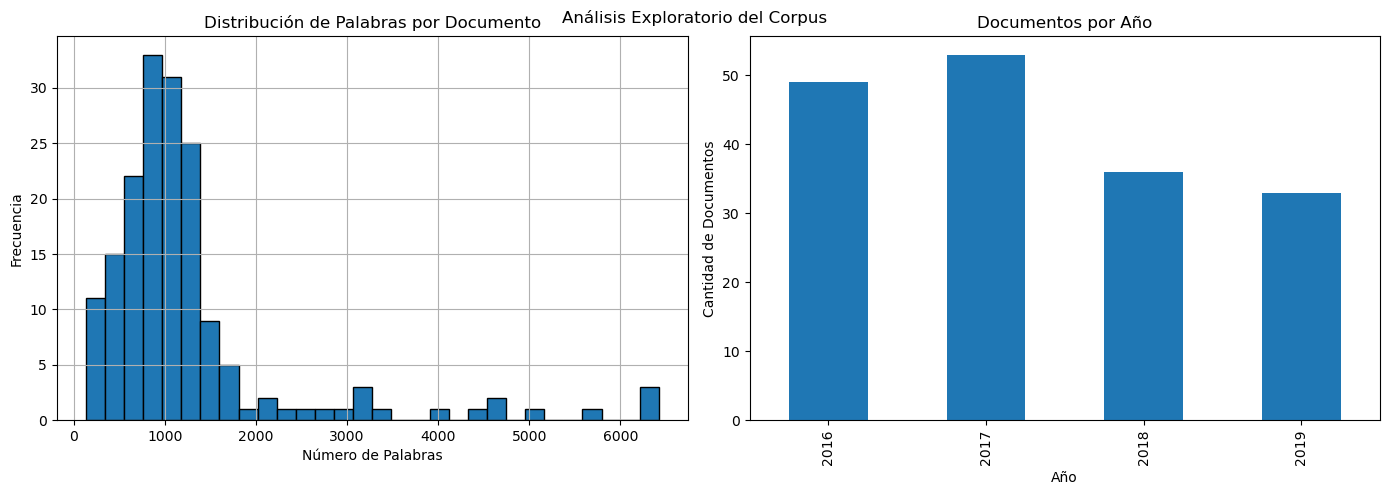


📈 Estadísticas del corpus:
       num_palabras  num_caracteres
count    171.000000      171.000000
mean    1268.754386     7467.087719
std     1116.494893     6673.781245
min      133.000000      779.000000
25%      732.500000     4279.000000
50%      991.000000     5794.000000
75%     1328.500000     7667.000000
max     6421.000000    39256.000000


In [19]:
# ========================================
# 5. ANÁLISIS EXPLORATORIO DEL CORPUS
# ========================================

# Distribución de longitud de documentos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['num_palabras'].hist(bins=30, ax=axes[0], edgecolor='black')
axes[0].set_title('Distribución de Palabras por Documento')
axes[0].set_xlabel('Número de Palabras')
axes[0].set_ylabel('Frecuencia')

# Documentos por año
df['año'].value_counts().sort_index().plot(kind='bar', ax=axes[1])
axes[1].set_title('Documentos por Año')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Cantidad de Documentos')

plt.tight_layout()
plt.suptitle('Análisis Exploratorio del Corpus')
plt.show()

# Estadísticas descriptivas
print("\n📈 Estadísticas del corpus:")
print(df[['num_palabras', 'num_caracteres']].describe())

In [49]:
# ========================================
# 6. PREPROCESAMIENTO CON NLTK/SPACY
# ========================================

# Stopwords en español
stop_words = set(stopwords.words('spanish'))

def preprocesar_texto(texto):
    """Limpia y tokeniza el texto"""
    # Minúsculas
    texto = texto.lower()
    
    # Tokenizar
    tokens = word_tokenize(texto, language='spanish')
    
    # Remover stopwords y puntuación
    tokens = [t for t in tokens if t.isalnum() and t not in stop_words]
    # concatenar tokens en un string
    return " ".join(tokens)

# Aplicar al primer documento
texto_limpio = preprocesar_texto(df.iloc[0]['texto'])
print(f"\n🧹 Texto limpio (primeras 20 palabras):")
print(texto_limpio.split()[:20])


🧹 Texto limpio (primeras 20 palabras):
['gracias', 'lindas', 'palabras', 'feliz', 'año', 'feliz', 'año', 'realmente', 'año', 'constructivo', 'año', 'trabajo', 'línea', 'argentina', 'soñamos', 'merecemos', 'verdad', 'alberto', 'digo', 'intendente']


In [50]:
docs_clean = [preprocesar_texto(t) for t in df['texto']]
docs_raw = df['texto']
# Keep alignment between raw and clean by filtering pairs together
pairs = [(r, c) for r, c in zip(docs_raw, docs_clean) if c.strip()]
docs_raw, docs_clean = zip(*pairs) if pairs else ([], [])
docs_raw, docs_clean = list(docs_raw), list(docs_clean)
print("Top tokens after preprocessing:", Counter(" ".join(docs_clean).split()).most_common(20))

Top tokens after preprocessing: [('argentina', 926), ('país', 755), ('argentinos', 720), ('años', 699), ('cada', 678), ('trabajo', 672), ('hoy', 652), ('hacer', 575), ('va', 567), ('acá', 531), ('vamos', 527), ('mundo', 522), ('ustedes', 497), ('ser', 481), ('gracias', 471), ('si', 420), ('hace', 406), ('vez', 384), ('día', 374), ('cosas', 372)]


In [52]:
len(docs_clean)

171

In [55]:
# -----------------------
# 4) Bag-of-words
# -----------------------
vectorizer = CountVectorizer(max_df=0.9, # max_df=0.9 para eliminar tokens que aparecen en más del 90% de los documentos
                            min_df=2, # min_df=2 para eliminar tokens que aparecen en menos de 2 documentos
                            ngram_range=(1, 3) # ngram_range=(1, 2) para considerar unigramas y bigramas
                            )
X = vectorizer.fit_transform(docs_clean)
vocab = np.array(vectorizer.get_feature_names_out())
print("Vocab size:", len(vocab))

Vocab size: 19723


In [57]:
RANDOM_SEED = 42
# -----------------------
# 5) Fit LDA
# -----------------------
n_topics = 5
lda = LatentDirichletAllocation(
    n_components=n_topics,
    learning_method="batch",
    random_state=RANDOM_SEED,
    max_iter=25
)
lda.fit(X)


,n_components,5
,doc_topic_prior,None
,topic_word_prior,None
,learning_method,'batch'
,learning_decay,0.7
,learning_offset,10.0
,max_iter,25
,batch_size,128
,evaluate_every,-1
,total_samples,1000000.0
,perp_tol,0.1


In [58]:
lda.components_

array([[ 9.4034465 ,  2.1999995 ,  0.20000011, ...,  3.18907478,
         0.20000023,  1.19999277],
       [ 4.35582134,  0.20000012,  0.20000023, ...,  0.20198185,
         0.2000005 ,  0.20000044],
       [36.49883828,  0.20000003,  3.19865709, ...,  3.19800233,
         1.19997179,  3.19582926],
       [ 1.54189326,  0.20000008,  0.20134209, ...,  0.21094029,
         1.20002642,  0.20417661],
       [ 0.20000062,  0.20000027,  0.20000049, ...,  0.20000075,
         0.20000106,  0.20000093]], shape=(5, 19723))

## Show topics (latent) and top words per topic

In [ ]:
# -----------------------
# 6) Topics: print + DataFrame of top words per topic
# -----------------------
def show_topics(model, vocab, top_n=12):
    """
    For each topic returned in the fit of LDA
    return the top_n words. This top are computed
    based on the estimated weights (pseudocounts that represents 
    the number of times word `j` was assigned to topic `i`.) of the LDA.

    Inputs:
    -------
        * model
        * vocab
        *

    """
    for k, weights in enumerate(model.components_):
        top_idx = np.argsort(weights)[::-1][:top_n]
        top_terms = [vocab[i] for i in top_idx]
        print(f"Topic {k}: {', '.join(top_terms)}")

def topics_dataframe(model, vocab, top_n=12):
    rows = []
    for topic_id, weights in enumerate(model.components_):
        top_idx = np.argsort(weights)[::-1][:top_n]
        for rank, i in enumerate(top_idx, start=1):
            rows.append({
                "topic_id": topic_id,
                "rank": rank,
                "term": vocab[i],
                "weight": float(weights[i]),
            })
    return pd.DataFrame(rows)

show_topics(lda, vocab, top_n=12)

df_topics = topics_dataframe(lda, vocab, top_n=12)

### Auxiliar functions

In [ ]:
def summarize_document(doc):
    """
    

    """
    # Stats básicas
    palabras = doc.split()
    print(f"\n📈 Estadísticas básicas:")
    print(f"  • Total palabras: {len(palabras):,}")
    print(f"  • Vocabulario único: {len(set(palabras)):,}")
    print(f"  • Promedio palabras/línea: {len(palabras)/(texto.count(chr(10))+1):.1f}")

    # Palabras más comunes
    from collections import Counter
    palabras_comunes = Counter(palabras).most_common(10)
    print(f"\n🔤 Top 10 palabras más frecuentes:")
    for palabra, freq in palabras_comunes:
        print(f"  {palabra:20s} → {freq:4d} veces")

# Apendix

## Dirichlet distribution

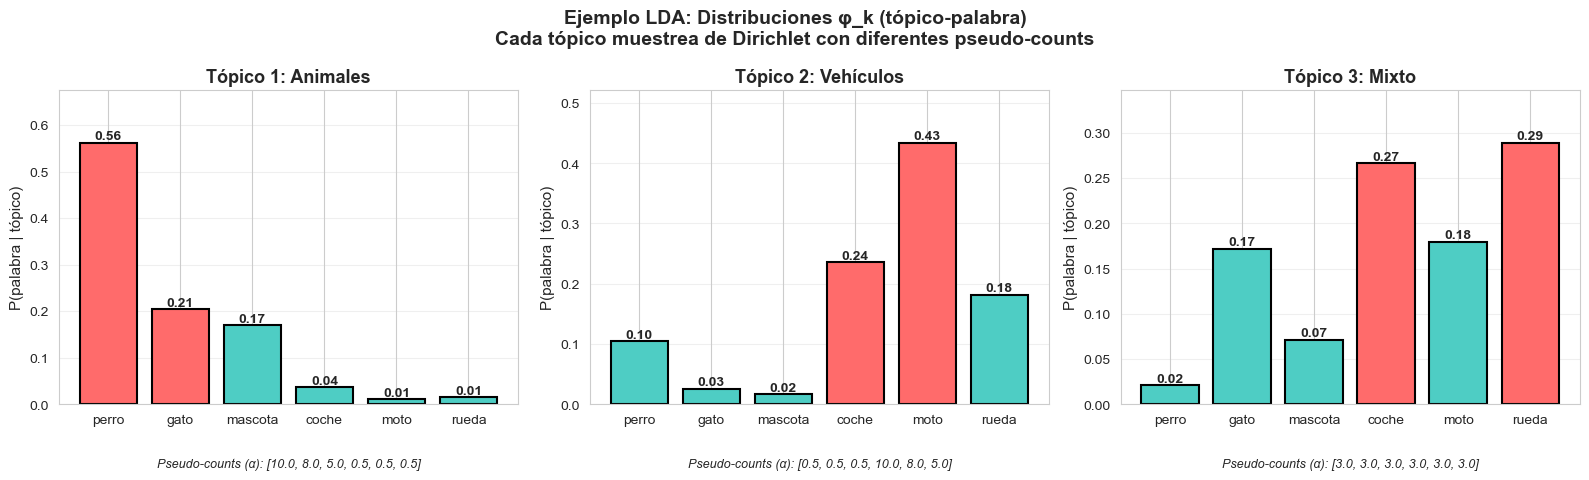

In [4]:
import sys
sys.path.append("../src")
from visualize_dirichlet import plot_dirichlet_2d, plot_lda_toy_example
from matplotlib import pyplot as plt
# Generar una visualización específica
fig = plot_lda_toy_example()
plt.show()

🎨 Generando visualizaciones de la distribución Dirichlet...

1️⃣ Dirichlet en 2D (Beta)...


/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:61: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:61: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


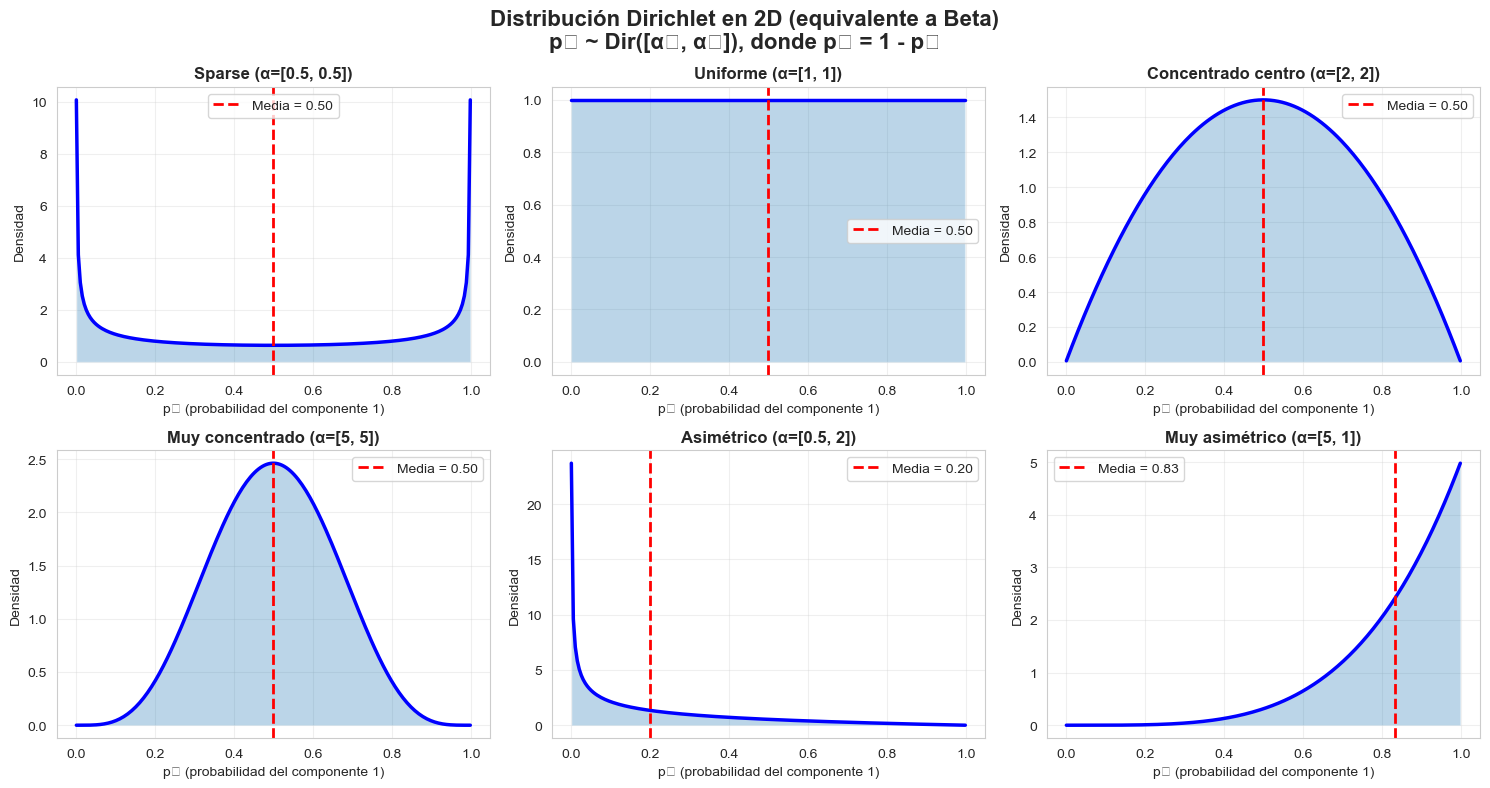

/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:107: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()



2️⃣ Dirichlet en 3D (Simplex)...


/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:107: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:107: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()
/opt/anaconda3/envs/nlp_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


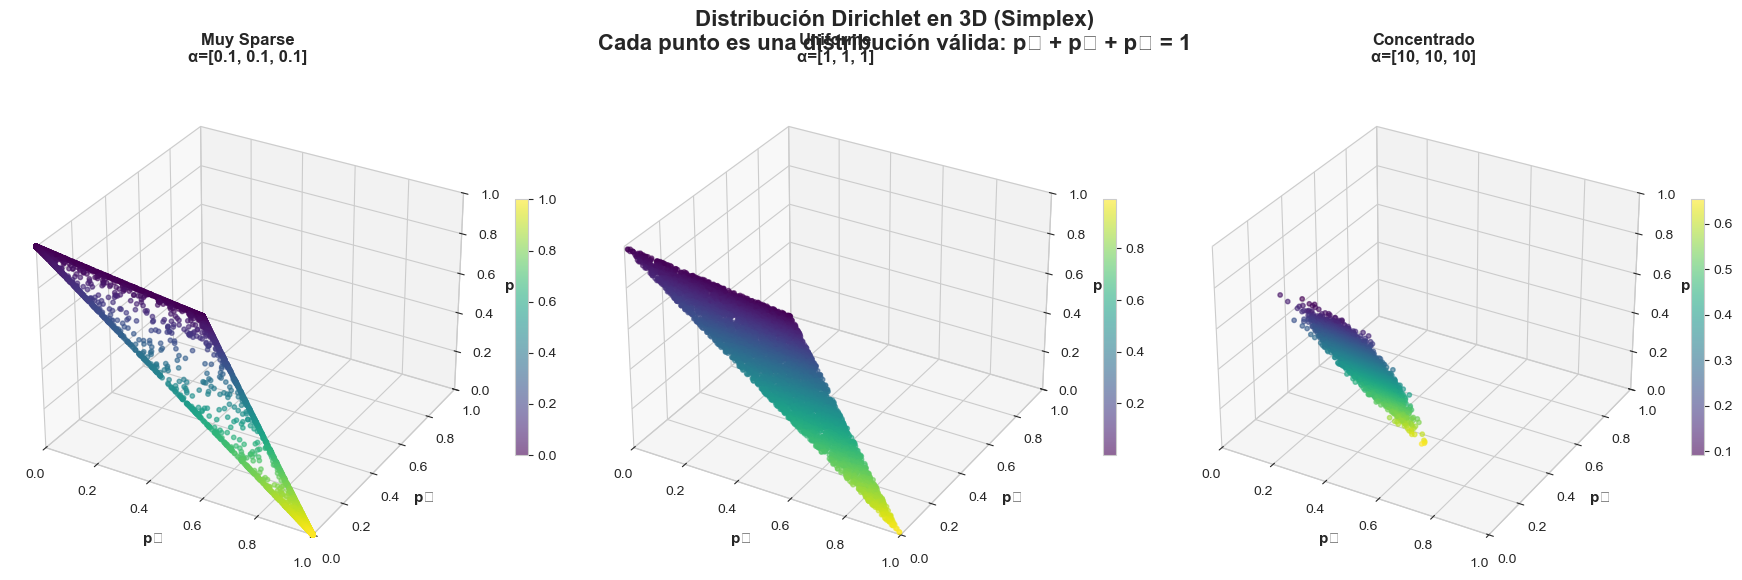


3️⃣ Proyección 2D del Simplex...


/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:160: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:160: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/david.damian/Desktop/RC/me/learning/advanced_nlp/module_2/src/visualize_dirichlet.py:160: UserWarning: Glyph 8323 (\N{SUBSCRIPT THREE}) missing from font(s) Arial.
  plt.tight_layout()


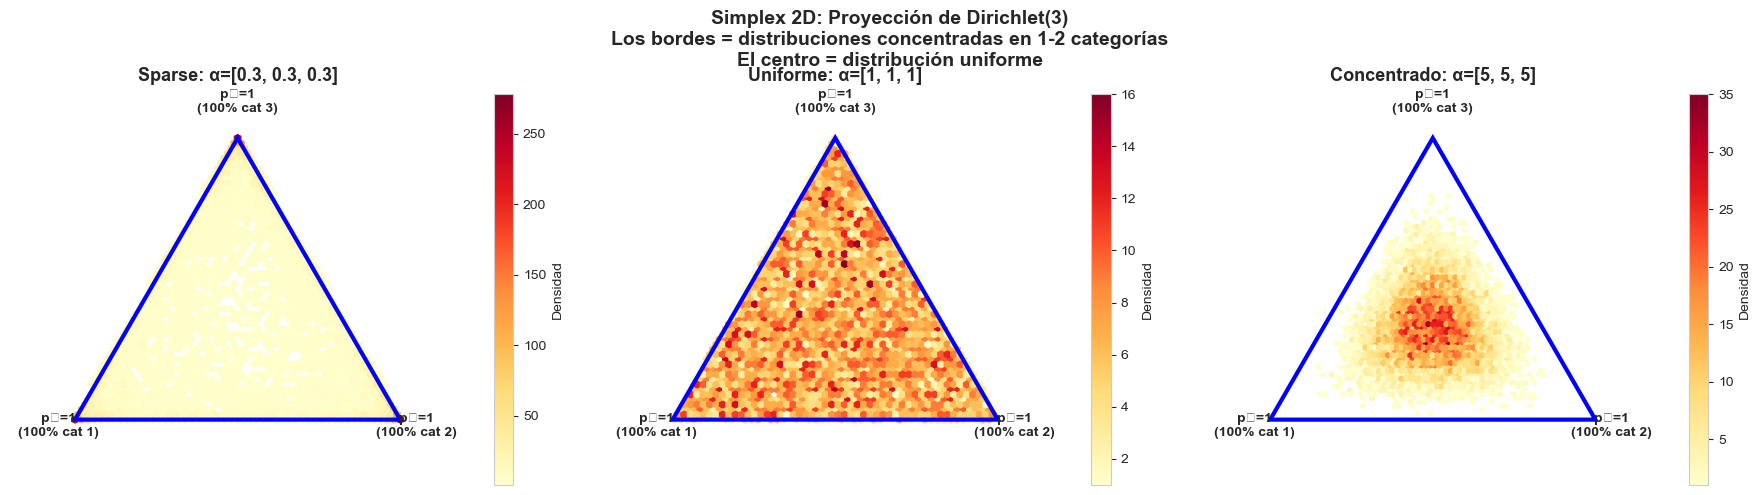


4️⃣ Efecto del parámetro α...


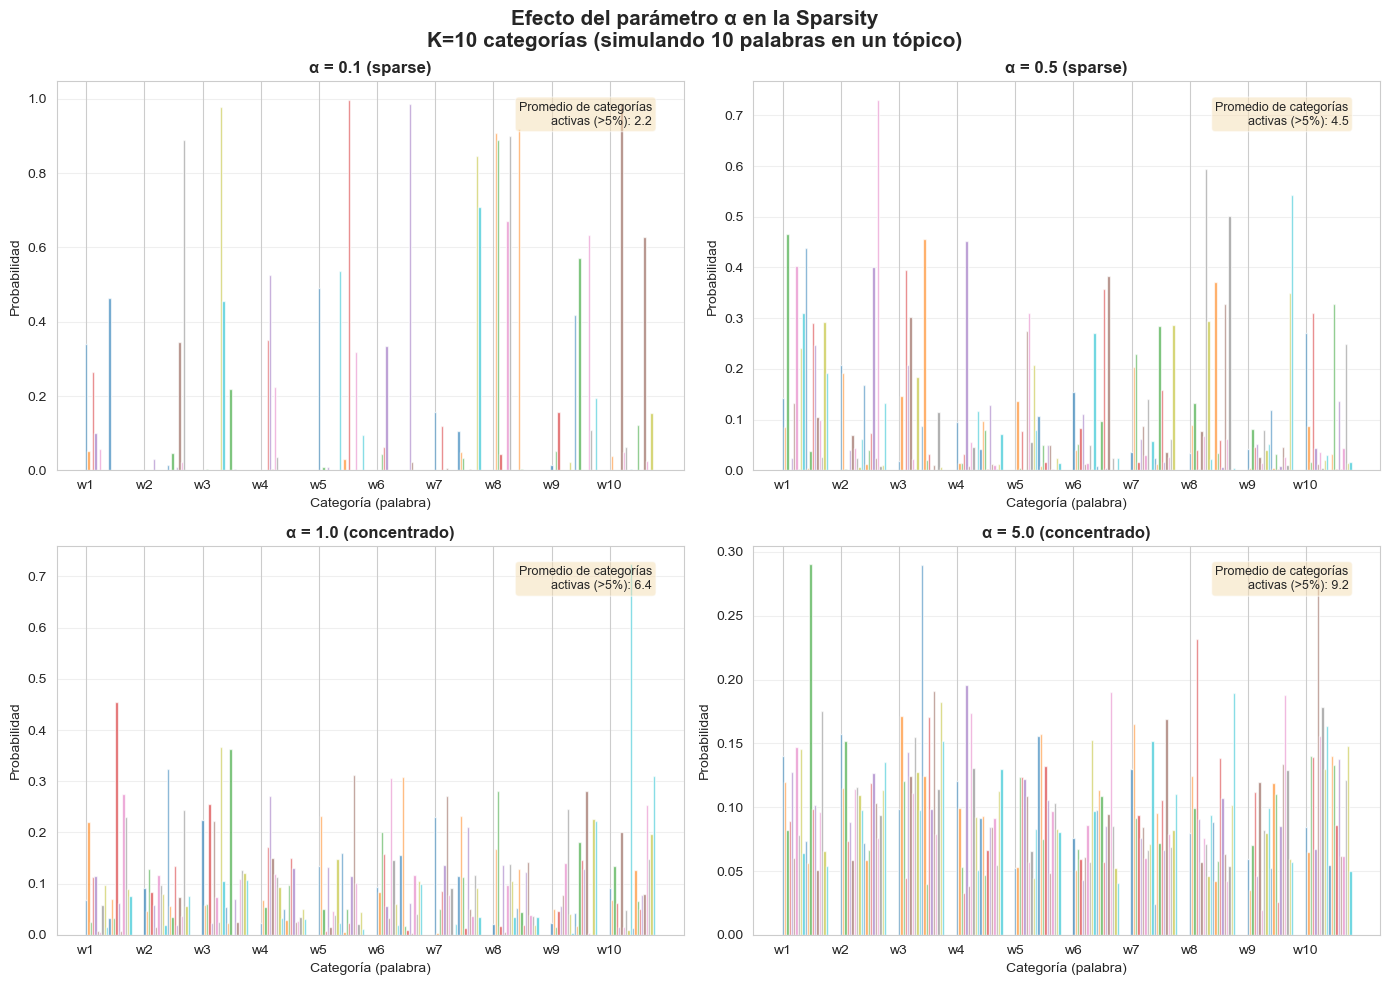


5️⃣ Ejemplo LDA con tópicos...


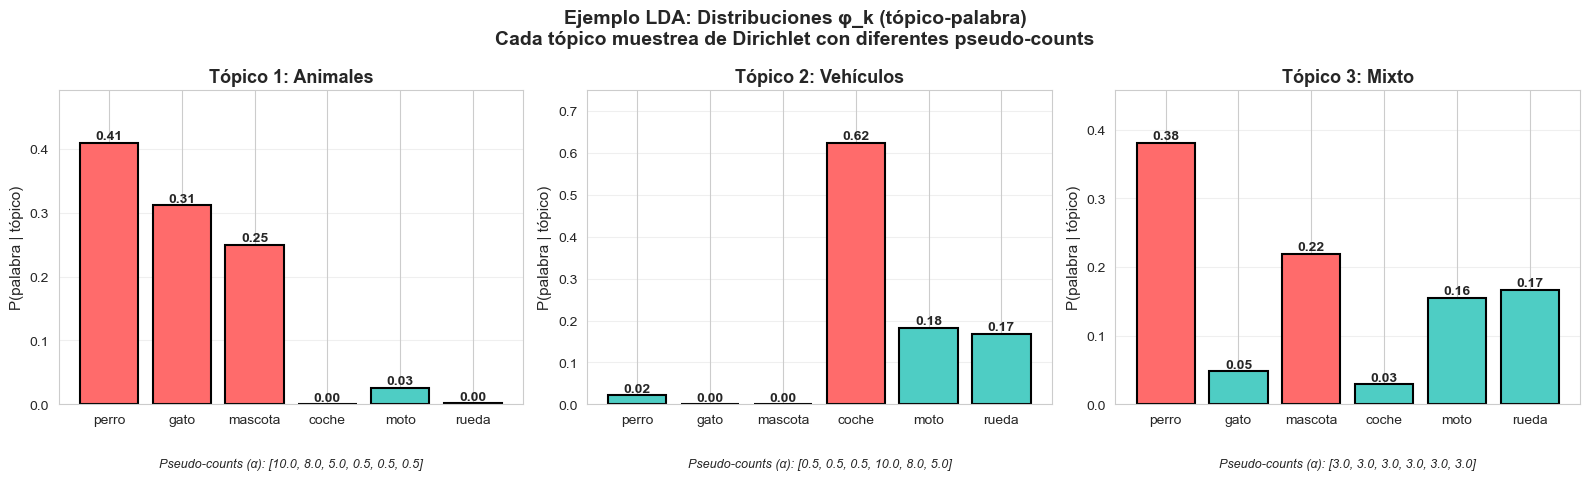


6️⃣ Prior vs Posterior...


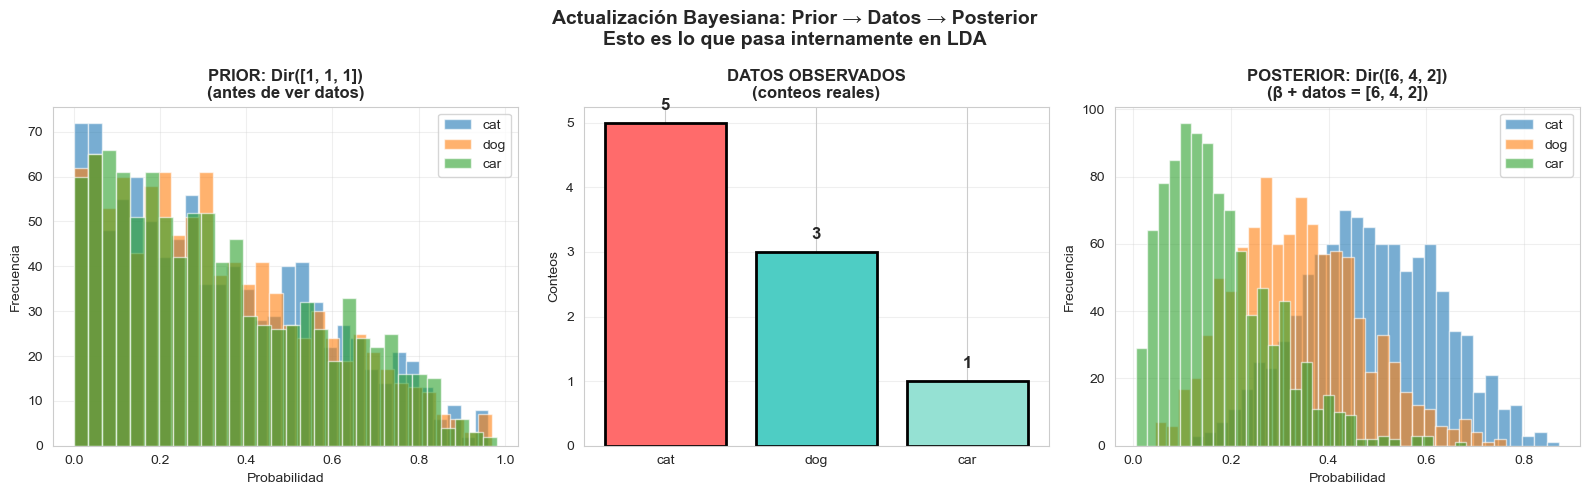


✅ ¡Todas las visualizaciones generadas!


In [6]:
%run ../src/visualize_dirichlet.py
